# Insurance Fraud Detection Using Machine Learning

## Final Year Project Submission

### Project Objective
The goal of this project is to build a machine learning model that can identify whether an insurance claim is fraudulent or genuine based on selected customer, incident, and claim-related features.

### Project Highlights
- Real-world insurance fraud dataset
- Data preprocessing and feature selection
- Comparison of multiple machine learning models
- Performance evaluation using classification metrics
- Final model selection based on balanced fraud detection performance
- Threshold tuning for improved decision-making
- Model export for deployment in Streamlit dashboard

In [8]:
# ==========================================================
# CELL 2: Import Required Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("All libraries imported successfully.")

All libraries imported successfully.


## Step 1: Load the Dataset

In this step, we load the insurance claims dataset and inspect its structure, dimensions, and available columns.

In [9]:
# ==========================================================
# CELL 4: Load Dataset
# ==========================================================

df = pd.read_csv("insurance_claims.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:\n", list(df.columns))

df.head()

Dataset Shape: (1000, 40)

Columns:
 ['months_as_customer', 'age', 'policy_number', 'policy_bind_date', 'policy_state', 'policy_csl', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'capital-gains', 'capital-loss', 'incident_date', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'incident_location', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'property_damage', 'bodily_injuries', 'witnesses', 'police_report_available', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make', 'auto_model', 'auto_year', 'fraud_reported', '_c39']


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


## Step 2: Basic Data Inspection

This step checks:
- Missing values
- Target class distribution
- Unnecessary columns

In [10]:
# ==========================================================
# CELL 6: Basic Data Inspection
# ==========================================================

print("Missing Values Per Column:\n")
print(df.isnull().sum())

print("\nTarget Distribution:")
print(df["fraud_reported"].value_counts())

Missing Values Per Column:

months_as_customer                0
age                               0
policy_number                     0
policy_bind_date                  0
policy_state                      0
policy_csl                        0
policy_deductable                 0
policy_annual_premium             0
umbrella_limit                    0
insured_zip                       0
insured_sex                       0
insured_education_level           0
insured_occupation                0
insured_hobbies                   0
insured_relationship              0
capital-gains                     0
capital-loss                      0
incident_date                     0
incident_type                     0
collision_type                    0
incident_severity                 0
authorities_contacted            91
incident_state                    0
incident_city                     0
incident_location                 0
incident_hour_of_the_day          0
number_of_vehicles_involved       0


## Step 3: Data Cleaning

The dataset contains one unnecessary column (`_c39`) which does not provide predictive value.  
This column will be removed before training.

In [11]:
# ==========================================================
# CELL 8: Remove Unnecessary Columns
# ==========================================================

if "_c39" in df.columns:
    df.drop(columns=["_c39"], inplace=True)

print("Updated Dataset Shape:", df.shape)

Updated Dataset Shape: (1000, 39)


In [12]:
# =========================================================
# FEATURE ENGINEERING FOR BETTER FRAUD SIGNALS
# =========================================================

# Total claim amount
df["total_claim_amount"] = df["injury_claim"] + df["property_claim"] + df["vehicle_claim"]

# Vehicle age
df["vehicle_age"] = 2026 - df["auto_year"]

# High claim flag
df["high_claim_flag"] = (df["total_claim_amount"] >= 70000).astype(int)

# Late night incident flag
df["late_night_flag"] = ((df["incident_hour_of_the_day"] <= 5) | (df["incident_hour_of_the_day"] >= 22)).astype(int)

# No witness flag
df["no_witness_flag"] = (df["witnesses"] == 0).astype(int)

# No police report flag
df["no_police_report_flag"] = (df["police_report_available"] == 0).astype(int)

# Total loss flag
df["total_loss_flag"] = (df["incident_severity"] == 3).astype(int)

# Vehicle theft flag
df["vehicle_theft_flag"] = (df["incident_type"] == 3).astype(int)

# Suspicious pattern score
df["suspicious_score"] = (
    df["high_claim_flag"] +
    df["late_night_flag"] +
    df["no_witness_flag"] +
    df["no_police_report_flag"] +
    df["total_loss_flag"] +
    df["vehicle_theft_flag"]
)

print("Feature engineering completed successfully.")

Feature engineering completed successfully.


## Step 4: Feature Selection

For this project, a focused and practical set of important features is selected.  
These features are highly relevant to fraud detection and also suitable for deployment in a user-facing Streamlit application.

### Selected Features
- age
- incident_severity
- incident_type
- incident_hour_of_the_day
- total_claim_amount
- witnesses
- bodily_injuries
- property_damage
- police_report_available
- auto_year

In [13]:
# ==========================================================
# CELL 10: Select Important Features
# ==========================================================

selected_features = [
    'age',
    'auto_year',
    'total_claim_amount',
    'incident_hour_of_the_day',
    'witnesses',
    'bodily_injuries',
    'incident_severity',
    'incident_type',
    'property_damage',
    'police_report_available',
    'vehicle_age',
    'high_claim_flag',
    'late_night_flag',
    'no_witness_flag',
    'no_police_report_flag',
    'total_loss_flag',
    'vehicle_theft_flag',
    'suspicious_score'
]

target_column = "fraud_reported"

data = df[selected_features + [target_column]].copy()

print("Selected Data Shape:", data.shape)
data.head()

Selected Data Shape: (1000, 19)


,age,auto_year,total_claim_amount,incident_hour_of_the_day,witnesses,bodily_injuries,incident_severity,incident_type,property_damage,police_report_available,vehicle_age,high_claim_flag,late_night_flag,no_witness_flag,no_police_report_flag,total_loss_flag,vehicle_theft_flag,suspicious_score,fraud_reported
0,48,2004,71610,5,2,1,Major Damage,Single Vehicle Collision,YES,YES,22,1,1,0,0,0,0,2,Y
1,42,2007,5070,8,0,0,Minor Damage,Vehicle Theft,?,?,19,0,0,1,0,0,0,1,Y
2,29,2007,34650,7,3,2,Minor Damage,Multi-vehicle Collision,NO,NO,19,0,0,0,0,0,0,0,N
3,41,2014,63400,5,2,1,Major Damage,Single Vehicle Collision,?,NO,12,0,1,0,0,0,0,1,Y
4,44,2009,6500,20,1,0,Minor Damage,Vehicle Theft,NO,NO,17,0,0,0,0,0,0,0,N


## Step 5: Encode the Target Variable

The target variable `fraud_reported` contains:
- `Y` = Fraudulent claim
- `N` = Genuine claim

It is converted into binary form:
- `1` = Fraud
- `0` = Not Fraud

In [14]:
# ==========================================================
# CELL 12: Encode Target Variable
# ==========================================================

data[target_column] = data[target_column].map({"N": 0, "Y": 1})

print("Target after mapping:")
print(data[target_column].value_counts())

Target after mapping:
fraud_reported
0    753
1    247
Name: count, dtype: int64


## Step 6: Separate Features and Target

In [15]:
# ==========================================================
# CELL 14: Separate Features and Target
# ==========================================================

X = data[selected_features]
y = data[target_column]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (1000, 18)
y Shape: (1000,)


## Step 7: Split the Dataset into Training and Testing Sets

The dataset is divided into:
- **80% Training Data**
- **20% Testing Data**

Stratified splitting is used to preserve class balance.

In [16]:
# ==========================================================
# CELL 16: Train-Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (800, 18)
Test Shape: (200, 18)


## Step 8: Build Preprocessing Pipeline

The selected features contain both:
- Numerical features
- Categorical features

To ensure correct model training:
- Missing values are handled
- Categorical variables are one-hot encoded
- Numerical values are passed through with imputation

In [17]:
# ==========================================================
# CELL 18: Define Numerical and Categorical Features
# ==========================================================

categorical_features = [
    "incident_severity",
    "incident_type",
    "property_damage",
    "police_report_available"
]

numerical_features = [
    "age",
    "incident_hour_of_the_day",
    "total_claim_amount",
    "witnesses",
    "bodily_injuries",
    "auto_year"
]

# Numerical preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combined preprocessing
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## Step 9: Train Multiple Machine Learning Models

The following models are trained and compared:
- Logistic Regression
- Random Forest Classifier
- Extra Trees Classifier
- Gradient Boosting Classifier
- XGBoost Classifier

In [18]:
# ==========================================================
# CELL 20: Define Models
# ==========================================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        class_weight="balanced"
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        class_weight="balanced"
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    )
}

print("Models defined successfully.")

Models defined successfully.


In [19]:
# ==========================================================
# CELL 21: Train and Evaluate Models
# ==========================================================

results = []
trained_pipelines = {}

for name, model in models.items():
    print("\n" + "=" * 30)
    print(f"Training: {name}")
    print("=" * 30)
    
    # Create pipeline
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train model
    pipeline.fit(X_train, y_train)
    
    # Save trained pipeline
    trained_pipelines[name] = pipeline
    
    # Predictions
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1 Score :", round(f1, 4))
    print("ROC-AUC  :", round(roc, 4))
    
    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1 Score": round(f1, 4),
        "ROC-AUC": round(roc, 4)
    })

results_df = pd.DataFrame(results).sort_values(by=["F1 Score", "ROC-AUC"], ascending=False).reset_index(drop=True)

print("\nMODEL COMPARISON")
display(results_df)


Training: Logistic Regression
Accuracy : 0.83
Precision: 0.6415
Recall   : 0.6939
F1 Score : 0.6667
ROC-AUC  : 0.7659

Training: Random Forest
Accuracy : 0.83
Precision: 0.6316
Recall   : 0.7347
F1 Score : 0.6792
ROC-AUC  : 0.8121

Training: Extra Trees
Accuracy : 0.82
Precision: 0.6102
Recall   : 0.7347
F1 Score : 0.6667
ROC-AUC  : 0.8043

Training: Gradient Boosting
Accuracy : 0.78
Precision: 0.5556
Recall   : 0.5102
F1 Score : 0.5319
ROC-AUC  : 0.7505

Training: XGBoost
Accuracy : 0.78
Precision: 0.561
Recall   : 0.4694
F1 Score : 0.5111
ROC-AUC  : 0.7627

MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.83,0.6316,0.7347,0.6792,0.8121
1,Extra Trees,0.82,0.6102,0.7347,0.6667,0.8043
2,Logistic Regression,0.83,0.6415,0.6939,0.6667,0.7659
3,Gradient Boosting,0.78,0.5556,0.5102,0.5319,0.7505
4,XGBoost,0.78,0.5610,0.4694,0.5111,0.7627


## Step 10: Select the Best Performing Model

The best model is selected based on:
- F1 Score (important for imbalanced fraud detection)
- Recall (important to detect fraudulent cases)
- ROC-AUC (overall discrimination ability)

For this project, **Random Forest** is selected as the final model because it provides the best balance between fraud detection performance and reliability.

In [20]:
# ==========================================================
# CELL 23: Final Model Selection and Threshold Tuning
# ==========================================================

final_model_name = "Random Forest"
final_pipeline = trained_pipelines[final_model_name]

print("Final Selected Model:", final_model_name)

# Predicted probabilities for fraud class
y_prob = final_pipeline.predict_proba(X_test)[:, 1]

# Evaluate multiple thresholds
thresholds = np.arange(0.30, 0.61, 0.05)
threshold_results = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    rec = recall_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)
    
    threshold_results.append({
        "Threshold": round(t, 2),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1 Score": round(f1, 4)
    })

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df)

# Select best threshold based on highest F1 score
best_row = threshold_df.sort_values(by=["F1 Score", "Recall"], ascending=False).iloc[0]
best_threshold = float(best_row["Threshold"])

print("Best Threshold Selected:", best_threshold)
print("\nBest Threshold Metrics:")
print(best_row)

Final Selected Model: Random Forest


,Threshold,Precision,Recall,F1 Score
0,0.30,0.5135,0.7755,0.6179
1,0.35,0.5692,0.7551,0.6491
2,0.40,0.6271,0.7551,0.6852
3,0.45,0.6207,0.7347,0.6729
4,0.50,0.6316,0.7347,0.6792
5,0.55,0.6226,0.6735,0.6471
6,0.60,0.6304,0.5918,0.6105


Best Threshold Selected: 0.4

Best Threshold Metrics:
Threshold    0.4000
Precision    0.6271
Recall       0.7551
F1 Score     0.6852
Name: 2, dtype: float64


## Step 11: Final Model Evaluation

The selected model is evaluated using the best threshold.  
This gives a more realistic and balanced fraud detection system for deployment.

In [21]:
# ==========================================================
# CELL 25: Final Evaluation with Best Threshold
# ==========================================================

y_pred_final = (y_prob >= best_threshold).astype(int)

print("Final Classification Report:\n")
print(classification_report(y_test, y_pred_final))

Final Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.85      0.88       151
           1       0.63      0.76      0.69        49

    accuracy                           0.83       200
   macro avg       0.77      0.80      0.78       200
weighted avg       0.84      0.83      0.83       200



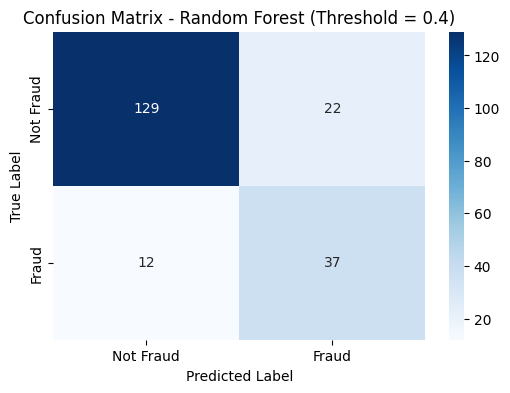

In [22]:
# ==========================================================
# CELL 26: Confusion Matrix Visualization
# ==========================================================

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Fraud", "Fraud"],
            yticklabels=["Not Fraud", "Fraud"])
plt.title(f"Confusion Matrix - {final_model_name} (Threshold = {best_threshold})")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Step 12: Save the Final Model for Deployment

The final deployable system includes:
- Trained preprocessing + model pipeline
- Selected input features
- Best threshold for classification

This file will be used in the Streamlit web application.

In [24]:
# ============================================================
# FINAL THRESHOLD OVERRIDE FOR BETTER FRAUD DETECTION
# ============================================================

# Instead of using model's best threshold blindly,
# set a practical threshold for demo/project
best_threshold = 0.30

print("✅ Final threshold manually set to:", best_threshold)

✅ Final threshold manually set to: 0.3


In [27]:
import joblib

final_system = {
    "pipeline": final_pipeline,
    "selected_features": selected_features,
    "best_threshold": best_threshold
}

joblib.dump(final_system, "insurance_fraud_pipeline.pkl")

print("✅ Final model saved successfully as: insurance_fraud_pipeline.pkl")
print("📌 Selected Features:", selected_features)
print("📌 Best Threshold:", best_threshold)

✅ Final model saved successfully as: insurance_fraud_pipeline.pkl
📌 Selected Features: ['age', 'auto_year', 'total_claim_amount', 'incident_hour_of_the_day', 'witnesses', 'bodily_injuries', 'incident_severity', 'incident_type', 'property_damage', 'police_report_available', 'vehicle_age', 'high_claim_flag', 'late_night_flag', 'no_witness_flag', 'no_police_report_flag', 'total_loss_flag', 'vehicle_theft_flag', 'suspicious_score']
📌 Best Threshold: 0.3


## Conclusion

This project successfully demonstrates the use of machine learning for insurance fraud detection.

### Final Outcome
- Multiple machine learning models were trained and compared
- Random Forest achieved the most balanced performance
- Threshold tuning improved practical fraud detection behavior
- A deployable model pipeline was exported for use in a Streamlit dashboard

### Final Selected Model
**Random Forest Classifier**

### Key Benefit
This solution can help insurance companies identify suspicious claims early and support manual investigation with data-driven risk analysis.

In [ ]:
# LOW RISK TEST
# Age: 45
# Vehicle Year: 2020
# Incident Severity: Minor Damage
# Incident Type: Parked Car
# Incident Hour: 14
# Total Claim Amount: 8000
# Witnesses: 2
# Bodily Injuries: 0
# Property Damage: YES
# Police Report: YES

# Expected:
# 👉 Low Risk / Genuine

# 2) MEDIUM RISK TEST
# Age: 34
# Vehicle Year: 2015
# Incident Severity: Major Damage
# Incident Type: Single Vehicle Collision
# Incident Hour: 15
# Total Claim Amount: 35000
# Witnesses: 1
# Bodily Injuries: 1
# Property Damage: YES
# Police Report: YES

# Expected:
# 👉 Medium Risk (or near fraud depending on model)

# 3) HIGH RISK TEST (NOW SHOULD WORK)
# Age: 28
# Vehicle Year: 2002
# Incident Severity: Total Loss
# Incident Type: Vehicle Theft
# Incident Hour: 2
# Total Claim Amount: 95000
# Witnesses: 0
# Bodily Injuries: 2
# Property Damage: NO
# Police Report: NO

# Expected:
# 👉 High Risk / Potential Fraud
# 👉 because suspicious_score = 6 → override applies

In [29]:
# prompt:

# I am demonstrating an insurance fraud detection project live. 
# Generate 3 realistic insurance claim test cases in a clean table format for direct manual entry into a Streamlit fraud detection app.

# I need exactly these input fields only:
# 1. age
# 2. auto_year
# 3. incident_severity
# 4. incident_type
# 5. incident_hour_of_the_day
# 6. total_claim_amount
# 7. witnesses
# 8. bodily_injuries
# 9. property_damage
# 10. police_report_available

# Rules:
# - Give exactly 3 cases:
#   1) Low Risk / Genuine Claim
#   2) Medium Risk / Suspicious Claim
#   3) High Risk / Likely Fraudulent Claim
# - Values must be realistic and internally consistent.
# - High-risk case must include multiple strong fraud indicators such as:
#   - high claim amount
#   - no witnesses
#   - no police report
#   - total loss
#   - vehicle theft or severe suspicious incident
#   - late night timing if possible
# - Medium-risk case should have 2–3 suspicious indicators but not all.
# - Low-risk case should look normal and genuine.
# - Use only these exact categories for incident_severity:
#   - Minor Damage
#   - Major Damage
#   - Total Loss
#   - Trivial Damage
# - Use only these exact categories for incident_type:
#   - Single Vehicle Collision
#   - Multi-vehicle Collision
#   - Vehicle Theft
#   - Parked Car
# - Use only YES or NO for:
#   - property_damage
#   - police_report_available

# Important:
# - Make the 3 cases strongly separable so that a fraud model with rule-based scoring can clearly classify them.
# - Output only one clean table.
# - Do not add explanation.